In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html
import numpy as np
from torch.utils.data import DataLoader
import awkward
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys

sys.path.append('../')
from helper import *


In [2]:
def collate_fn_transformer(batch):
    """
    Custom function that defines how batches are formed.

    To process the batch items that each have a different number of hits, it is efficient
    to first concatenate all the data into a single tensor and save the lengths of each
    individual event to be able to split the data again later.

    # F: input_dim, number of features (time, x, y)
    # N: number of hits (different for each event)
    # B: batch size

    The resulting 2D tensor has the shape (B x N, F) where B is the batch size, N is the total number of hits of all events
    in the batch, and F is the number of features (time, x, y).


    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []
    lengths=[]

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        lengths.append(tensordata.shape[0])

        data_list.append(tensordata)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor

    data_vec=torch.cat(data_list) # (B, N, F)  -> (BxN, F) where B is the batch size, N is the number of hits, and F is the number of features (time, x, y)

    ## return a list [datalist, lengths]
    return [data_vec, lengths], labels

In [3]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim = 3,
        d_model = 64,
        output_dim = 2,
        nhead = 4,
        dim_feedforward = 128,
        num_layers = 2,

    ):
        super().__init__()

        # Hint: define the input embedding layer
        self.input_embedding = nn.Linear(input_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
            d_model = d_model,
            nhead = nhead,
            dim_feedforward = dim_feedforward,
            activation="relu",
            batch_first=True,
            norm_first=True,
            dropout=0.02
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers) # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html
        self.pos_embedding = nn.Parameter(torch.randn(1, 1000, d_model) * 0.01)

        # Attention pooling
        self.attention_pool = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Tanh(),
            nn.Linear(d_model, 1)
        )

        # Hint: define the output projection layer
        self.output_projection = nn.Sequential(nn.Linear(d_model, d_model // 2),
                                                nn.ReLU(),
                                                nn.Dropout(0.1),
                                                nn.Linear(d_model // 2, output_dim))

    def forward(self, data) -> torch.Tensor:
        """
        Args:
            data: list of (src tensor, lengths)
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: d_model, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
            # shape (B x N, F) -> (B x N, D)
        x = self.input_embedding(src) 

        # 2) split the data into a list of tensors, one for each event
        parts = x.split(lengths, dim=0)  # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
                                            # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event


        # 3) pad inputs with zeros so that all batch items have same length
        padded = pad_sequence(parts, batch_first=True) # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length
        B, L, D = padded.shape
        padded = padded + self.pos_embedding[:, :L, :]

        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(B, L , dtype=torch.bool, device=padded.device)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # # 6) masked mean‐pool, i.e., form the average for every batch item along the sequence dimension
        # # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item
        # # we need to ignore the padding tokens in the mean pooling
        # # the resulting shape is (B, D)
        # valid_mask = ~mask
        # summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        # lengths_tensor = torch.tensor(lengths, device=padded.device, dtype= torch.float32).unsqueeze(1) # (B, 1)
        # pooled = summed / lengths_tensor # (B, D)

        # 6) Attention pooling
        # shape: (B, max_len, 1)
        attn_scores = self.attention_pool(enc_out)

        # shape: (B, max_len)
        attn_scores = attn_scores.squeeze(-1)

        # Mask padded positions
        attn_scores = attn_scores.masked_fill(mask, -1e9)

        # Normalize attention weights
        attn_weights = torch.softmax(attn_scores, dim=1)

        # Weighted sum
        # shape: (B, D)
        pooled = torch.sum(
            enc_out * attn_weights.unsqueeze(-1),
            dim=1
        )

        # 7) apply a final linear layer to get the output of shape (B, output_dim)
        return self.output_projection(pooled)

In [4]:
# Hyperparams
DATA_PATH = "dataset"
BATCH_SIZE = 128


config = {
    "epochs":       200,
    "lr":           1e-4,
    "loss":         nn.MSELoss(),
    "optimizer":    "adam",
    "cosine":       {"T_max": 200},
    "early_stop":   {"patience": 15},
    "save_path":    "logs/transformer_icecube_train_log.csv",
    "model_name":   "transformer_icecube",
}

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [5]:
# Load raw datasets

train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset   = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset  = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

In [6]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

In [7]:
# Normalize data

t_mean = awkward.mean(train_dataset["data"][:, 0, :])
t_std  = awkward.std(train_dataset["data"][:, 0, :])

x_mean = awkward.mean(train_dataset["data"][:, 1, :])
x_std  = awkward.std(train_dataset["data"][:, 1, :])

y_mean = awkward.mean(train_dataset["data"][:, 2, :])
y_std  = awkward.std(train_dataset["data"][:, 2, :])

xpos_mean = awkward.mean(train_dataset["xpos"])
xpos_std  = awkward.std( train_dataset["xpos"])

ypos_mean = awkward.mean(train_dataset["ypos"])
ypos_std  = awkward.std( train_dataset["ypos"])

In [8]:
def normalise_dataset(ds):
    norm_t = (ds["data"][:, 0:1, :] - t_mean) / t_std
    norm_x = (ds["data"][:, 1:2, :] - x_mean) / x_std
    norm_y = (ds["data"][:, 2:3, :] - y_mean) / y_std
    ds["data"] = awkward.concatenate([norm_t, norm_x, norm_y], axis=1)
    ds["xpos"] = (ds["xpos"] - xpos_mean) / xpos_std
    ds["ypos"] = (ds["ypos"] - ypos_mean) / ypos_std
    return ds

In [9]:
train_dataset = normalise_dataset(train_dataset)
val_dataset   = normalise_dataset(val_dataset)
test_dataset  = normalise_dataset(test_dataset)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn_transformer)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_transformer)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_transformer)

In [11]:
model = TransformerEncoder()
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} parameters.")

Model has 137,571 parameters.


c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [12]:
def train_model(model, train_loader, val_loader, config, device):
    epochs = config["epochs"]
    lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.0)
    save_path = config.get("save_path", "train_log.csv")

    if config["optimizer"].lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif config["optimizer"].lower() == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("Unsupported optimizer")

    loss_fn = config.get("loss_fn", torch.nn.MSELoss())

    scheduler = None
    scheduler_type = None
    if config.get("cosine"):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["cosine"].get("T_max", epochs))
        scheduler_type = "cosine"
    elif config.get("plateau"):
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min",
            factor=config["plateau"].get("factor", 0.1),
            patience=config["plateau"].get("patience", 5))
        scheduler_type = "plateau"

    early_stop_patience = config["early_stop"].get("patience", 10) if config.get("early_stop") else None
    best_val_loss = float("inf")
    epochs_no_improve = 0

    model.to(device)
    train_losses, val_losses = [], []

    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    with open(save_path, mode="w", newline="") as f:
        csv.writer(f).writerow(["epoch", "train_loss", "val_loss", "learning_rate"])

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0.0
        for (data_vec, lengths), y_batch in train_loader:          
            data_vec = data_vec.to(device)
            y_batch  = y_batch.to(device)

            optimizer.zero_grad()
            preds = model([data_vec, lengths])
            loss  = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validate 
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (data_vec, lengths), y_batch in val_loader:        
                data_vec = data_vec.to(device)
                y_batch  = y_batch.to(device)
                preds     = model([data_vec, lengths])
                val_loss += loss_fn(preds, y_batch).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        with open(save_path, mode="a", newline="") as f:
            csv.writer(f).writerow([epoch, train_loss, val_loss, current_lr])

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {current_lr:.6f}")

        if scheduler:
            scheduler.step(val_loss) if scheduler_type == "plateau" else scheduler.step()

        if early_stop_patience:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                torch.save(model.state_dict(), f"best_model_{config['model_name']}.pth")
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= early_stop_patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    return train_losses, val_losses


def evaluate_model(model, test_loader, device, config, precomputed=False):
    if precomputed:
        path = f"best_model_{config['model_name']}.pth"
        if os.path.exists(path):
            model.load_state_dict(torch.load(path, map_location=device))
            print(f"Loaded weights from {path}")
        else:
            print(f"Warning: {path} not found")

    model.to(device)
    model.eval()

    preds_list, y_true_list = [], []
    total_mse, total_samples = 0.0, 0

    with torch.no_grad():
        for (data_vec, lengths), y_batch in test_loader:          
            data_vec = data_vec.to(device)
            y_batch  = y_batch.to(device)

            preds = model([data_vec, lengths])

            total_mse     += torch.mean((preds - y_batch) ** 2).item() * y_batch.size(0)
            total_samples += y_batch.size(0)

            preds_list.append(preds.cpu().numpy())
            y_true_list.append(y_batch.cpu().numpy())

    print(f"Average test MSE: {total_mse / total_samples:.4f}")
    return np.vstack(preds_list), np.vstack(y_true_list)

In [13]:
# # Train
# train_losses, val_losses = train_model(model = model, train_loader = train_loader, val_loader = val_loader, config = config, device = DEVICE)

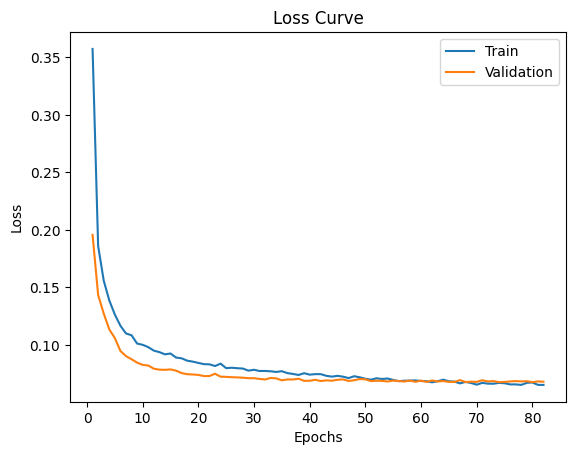

In [14]:
plot_loss(log_path=config["save_path"], savefig=True, exclude_first=True)

In [15]:
# Evaluate
preds_norm, y_true_norm = evaluate_model(model = model, test_loader = test_loader, device = DEVICE, config = config, precomputed = True)

C:\Users\hynda\AppData\Local\Temp\ipykernel_28068\3434799872.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device)

Loaded weights from best_model_transformer_icecube.pth
Average test MSE: 0.0637


In [16]:
# Denormalize for plotting
label_mean = np.array([xpos_mean, ypos_mean])
label_std  = np.array([xpos_std,  ypos_std])

preds  = preds_norm  * label_std + label_mean
y_true = y_true_norm * label_std + label_mean

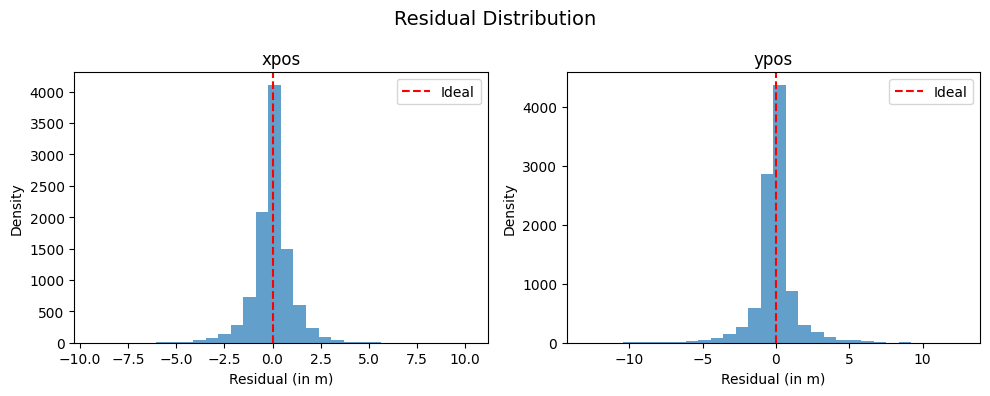


-- Test-set residual statistics --
  xpos: mean=0.0079 m | std=1.0508 m | MAE=0.6817 m
  ypos: mean=-0.0329 m | std=1.4323 m | MAE=0.8205 m


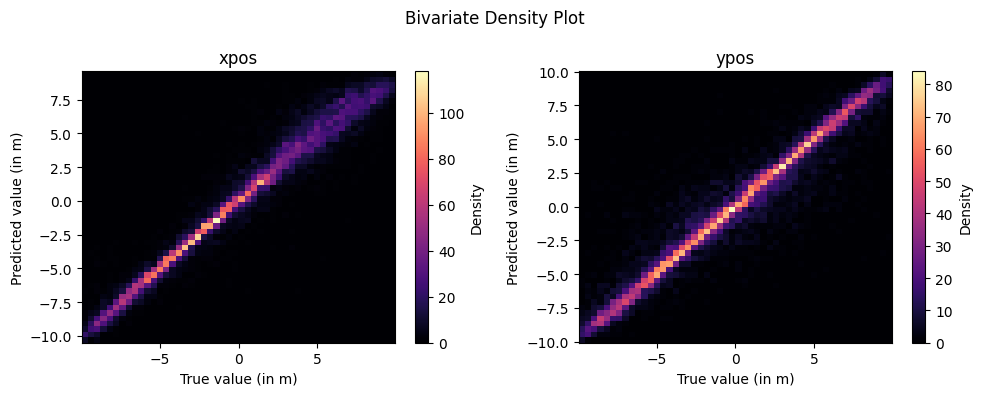

In [17]:
# Plots

label_names = ["xpos", "ypos"]
label_units = ["m", "m"]
plot_residuals(y_true, preds, label_names, label_units, savefig=True)


residuals = y_true - preds
print("\n-- Test-set residual statistics --")
for i, name in enumerate(label_names):
    print(f"  {name}: mean={residuals[:,i].mean():.4f} m | "
        f"std={residuals[:,i].std():.4f} m | "
        f"MAE={np.abs(residuals[:,i]).mean():.4f} m")
    
plot_heatmap(y_true, preds, label_names, label_units, savefig=True)

In [20]:
def plot_event(dataset, event_idx, pred_x=None, pred_y=None,
                label_mean=None, label_std=None):

    times = awkward.to_numpy(dataset["data"][event_idx, 0, :])
    hits_x = awkward.to_numpy(dataset["data"][event_idx, 1, :])
    hits_y = awkward.to_numpy(dataset["data"][event_idx, 2, :])

    # denormalize
    true_x = dataset["xpos"][event_idx] * label_std[0] + label_mean[0]
    true_y = dataset["ypos"][event_idx] * label_std[1] + label_mean[1]

    fig, ax = plt.subplots(figsize=(7, 6))

    sc = ax.scatter(hits_x, hits_y, c=times, cmap="plasma", s=15)
    plt.colorbar(sc, ax=ax, label = "Hit time (in ns)")

    ax.scatter(true_x, true_y, c="green", s=75, marker="*",
                label="True")

    if pred_x is not None:
        err = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)
        ax.scatter(pred_x, pred_y, c="blue", s=75, marker="X",
                label=f"Pred : Error = {err:.3f}m")

        ax.plot([true_x, pred_x], [true_y, pred_y], '--')


    ax.grid(alpha = 0.6)
    ax.legend()

    # Fixed detector view
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)

    ax.set_aspect('equal')
    
    plt.title(f"Neutrino Event {event_idx}")
    plt.xlabel("x_pos (in m)")
    plt.ylabel("y_pos (in m)")
    # plt.savefig(f"plots/event_{event_idx}.png", dpi = 300)
    plt.show()

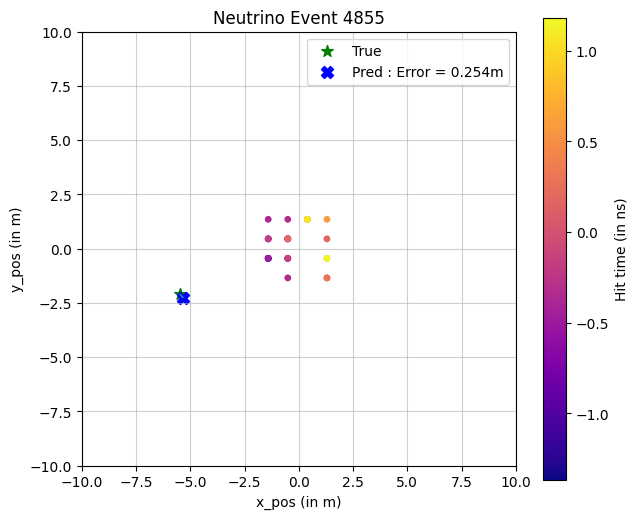

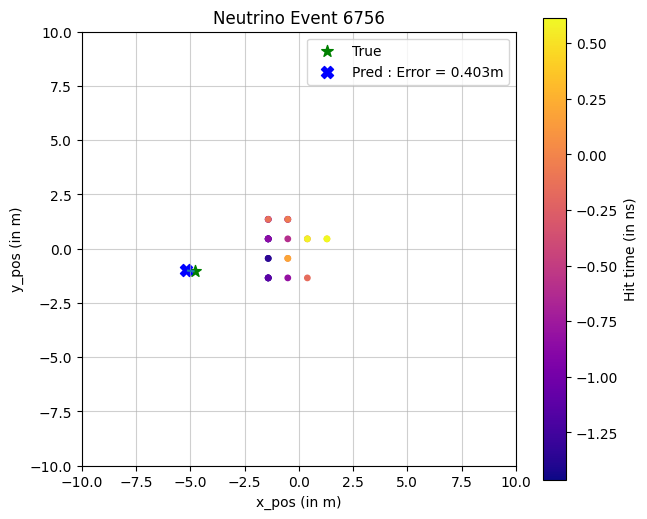

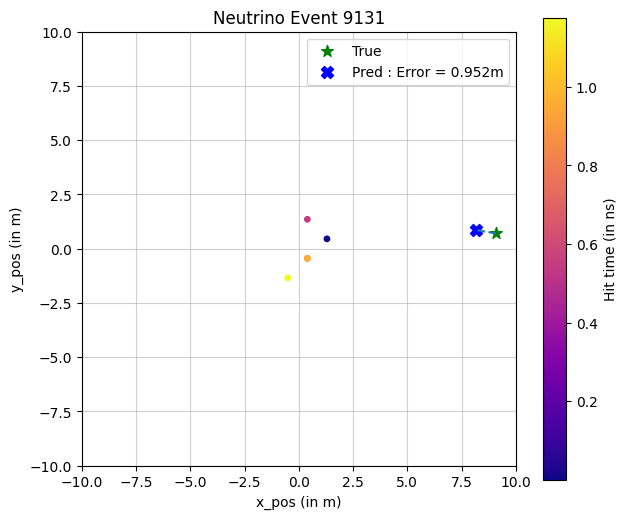

In [33]:
nums = np.random.choice(len(test_dataset), 3, replace=False)

for i in nums:
    plot_event(test_dataset, i, pred_x=preds[i, 0], pred_y=preds[i, 1], label_mean = label_mean, label_std = label_std)